# Censored Demand Analysis

**Goal**: Analyze the impact of stockouts or observed demand and identify high-risk stores

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
warnings.filterwarnings("ignore")

# Set style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries Loaded")

Libraries Loaded


## 1. Load the data

In [3]:
# Load the dataset
df = pd.read_parquet('../data/generated/sales_data.parquet')

df['date'] = pd.to_datetime(df['date'])

In [4]:
print("Dataset shape:", df.shape)
print(f"Date range: {df['date'].min()} - {df['date'].max()}")
print("\nKey Columns:")
print("* demand: True Demand (units)")
print("* sales_qty: Actual Sales (capped by inventory)")
print("* inventory: Stock available")
print("* stockout_flag: 1 if demand > inventory")
print("* lost_sales: demand - sales_qty (if demand > inventory)")

display(df[['date', 'store', 'category', 'demand', 'sales_qty', 'inventory', 'stockout_flag', 'lost_sales']].head(10))

Dataset shape: (2883231, 55)
Date range: 2016-01-01 00:00:00 - 2026-08-26 00:00:00

Key Columns:
* demand: True Demand (units)
* sales_qty: Actual Sales (capped by inventory)
* inventory: Stock available
* stockout_flag: 1 if demand > inventory
* lost_sales: demand - sales_qty (if demand > inventory)


,date,store,category,demand,sales_qty,inventory,stockout_flag,lost_sales
0,2016-01-01,Bandra Hub,Electronics,11,11,12,0,0
1,2016-01-01,Bandra Hub,Electronics,33,33,39,0,0
2,2016-01-01,Bandra Hub,Electronics,34,34,49,0,0
3,2016-01-01,Bandra Hub,Electronics,23,23,25,0,0
4,2016-01-01,Bandra Hub,Electronics,15,15,18,0,0
5,2016-01-01,Bandra Hub,Clothing,45,45,50,0,0
6,2016-01-01,Bandra Hub,Clothing,49,49,57,0,0
7,2016-01-01,Bandra Hub,Clothing,60,60,89,0,0
8,2016-01-01,Bandra Hub,Clothing,24,24,33,0,0
9,2016-01-01,Bandra Hub,Clothing,14,14,15,0,0


## 2. Overview Statistics: Censoring Problem

In [5]:
print("CENSORING PROBLEM OVERVIEW")
print("="*70)

# GLobal censoring rate
total_rows = len(df)
censored_rows = df['stockout_flag'].sum()
censored_rate = censored_rows / total_rows

print(f"\n Total Observations: {total_rows:,}")
print(f"Censored (Stockout): {censored_rows:,} ({censored_rate*100:.2f}%)")
print(f"Uncensored: {total_rows - censored_rows:,} ({(1-censored_rate)* 100:.2f}%)")

CENSORING PROBLEM OVERVIEW

 Total Observations: 2,883,231
Censored (Stockout): 822,530 (28.53%)
Uncensored: 2,060,701 (71.47%)


In [6]:
# Lost Sales Impact
total_lost_sales = df['lost_sales'].sum()
total_actual_sales = df['sales_qty'].sum()
true_demand_sum = df['demand'].sum()

print("\nREVENUE IMPACT")
print(f"Total Actual Sales (qty): {total_actual_sales:,}")
print(f"Total Lost Sales (qty): {total_lost_sales:,}")
print(f"True Demand(qty): {true_demand_sum:,}")
print(f"Lost as % of True Demand: {(total_lost_sales / true_demand_sum) * 100:.2f}%")


REVENUE IMPACT
Total Actual Sales (qty): 165,840,506
Total Lost Sales (qty): 5,315,734
True Demand(qty): 171,156,240
Lost as % of True Demand: 3.11%


In [7]:
# Estimated lost revenue
avg_price = df['final_price'].mean()
estimated_lost_revenue = total_lost_sales * avg_price
print(f"\nEstimated Lost Revenue: Rs.{estimated_lost_revenue:,.0f}")


Estimated Lost Revenue: Rs.71,304,646,924


In [8]:
# Distribution of Censoring
print(f"\nCENSORING DISTRIBUTION:")
censoring_dist = pd.cut(
    df.groupby('store_id')['stockout_flag'].mean(),
    bins = [0, 0.1, 0.2, 0.3, 0.5, 1.0],
    labels = ['0-10%', '10-20%', '20-30%', '30-50%', '50-100%']
)
print(censoring_dist.value_counts().sort_index())


CENSORING DISTRIBUTION:
stockout_flag
0-10%       0
10-20%      0
20-30%     37
30-50%      0
50-100%     0
Name: count, dtype: int64


## 3. Estimated True Demand

In [9]:
# Calculate estimated true demand
# For uncensored: use observed demand
# For censored: add back lost sales to obsereved

df['estimated_true_demand'] = df['demand'].copy()
# Demand already includes lost_sales for censored cases in synthetic data, so we don't need to add lost_sales again.

print("DEMAND COMPARISON")
print("="*70)

comparison = df[['demand', 'sales_qty', 'inventory', 'lost_sales', 'estimated_true_demand']].describe()
print(comparison)

DEMAND COMPARISON


             demand     sales_qty     inventory    lost_sales  \
count  2.883231e+06  2.883231e+06  2.883231e+06  2.883231e+06   
mean   5.936265e+01  5.751898e+01  6.776669e+01  1.843673e+00   
std    6.380661e+01  6.217109e+01  7.544788e+01  5.237837e+00   
min    1.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    1.800000e+01  1.800000e+01  2.000000e+01  0.000000e+00   
50%    3.600000e+01  3.500000e+01  4.100000e+01  0.000000e+00   
75%    7.700000e+01  7.500000e+01  8.800000e+01  1.000000e+00   
max    9.470000e+02  9.470000e+02  1.331000e+03  1.410000e+02   

       estimated_true_demand  
count           2.883231e+06  
mean            5.936265e+01  
std             6.380661e+01  
min             1.000000e+00  
25%             1.800000e+01  
50%             3.600000e+01  
75%             7.700000e+01  
max             9.470000e+02  


In [10]:
print("\n🔍 Examples of Censored vs Uncensored Observations:")
print("\nCENSORED (Stockout):")
display(df[df['stockout_flag'] == 1][['date', 'store', 'category', 'demand', 'sales_qty', 'inventory', 'lost_sales']].head(5))

print("\nUNCENSORED (No Stockout):")
display(df[df['stockout_flag'] == 0][['date', 'store', 'category', 'demand', 'sales_qty', 'inventory', 'lost_sales']].head(5))


🔍 Examples of Censored vs Uncensored Observations:

CENSORED (Stockout):


,date,store,category,demand,sales_qty,inventory,lost_sales
16,2016-01-01,Bandra Hub,Grocery,69,61,61,8
20,2016-01-01,Borivali Plaza,Electronics,35,32,32,3
30,2016-01-01,Borivali Plaza,Clothing,53,50,50,3
34,2016-01-01,Borivali Plaza,Grocery,53,49,49,4
37,2016-01-01,Borivali Plaza,Grocery,94,78,78,16



UNCENSORED (No Stockout):


,date,store,category,demand,sales_qty,inventory,lost_sales
0,2016-01-01,Bandra Hub,Electronics,11,11,12,0
1,2016-01-01,Bandra Hub,Electronics,33,33,39,0
2,2016-01-01,Bandra Hub,Electronics,34,34,49,0
3,2016-01-01,Bandra Hub,Electronics,23,23,25,0
4,2016-01-01,Bandra Hub,Electronics,15,15,18,0


## 4. Store-Level Censoring Analysis

In [11]:
# Aggregate by store
store_censoring = df.groupby('store_id').agg({
    'store': 'first',
    'city': 'first',
    'region': 'first',
    'stockout_flag': ['sum', 'mean'],
    'lost_sales': 'sum',
    'sales_qty': 'sum',
    'demand': 'sum',
    'final_price': 'mean',
    'date': 'count'
}).reset_index(drop = True)

In [12]:
store_censoring.columns = [
    'store', 'city', 'region', 'stockouts_count', 'censoring_rate', 
    'lost_sales_units', 'actual_sales_units', 'true_demand_units',
    'avg_price', 'total_records'
]
store_censoring['estimated_lost_revenue'] = store_censoring['lost_sales_units'] * store_censoring['avg_price']

store_censoring.sort_values(by = 'censoring_rate', ascending = False)

print("\nTOP 15 STORES BY CENSORING RATE:")
print("="*70)
display(store_censoring.sort_values('censoring_rate', ascending = False).head(15))

print("\nTOP 15 STORES BY LOST REVENUE")
print("="*70)
display(store_censoring.sort_values('estimated_lost_revenue', ascending = False).head(15))


TOP 15 STORES BY CENSORING RATE:


,store,city,region,stockouts_count,censoring_rate,lost_sales_units,actual_sales_units,true_demand_units,avg_price,total_records,estimated_lost_revenue
7,Dharampeth Market,Nagpur,Maharashtra,22461,0.288628,134082,4059142,4193224,10432.807263,77820,1.398852e+09
34,Maninagar Outlet,Ahmedabad,Gujarat,20183,0.288172,108965,3323857,3432822,11730.820600,70038,1.278249e+09
29,Karol Bagh Mart,New Delhi,Delhi,23533,0.288003,194147,6102669,6296816,11830.331182,81711,2.296823e+09
30,Lajpat Nagar Hub,New Delhi,Delhi,23487,0.287440,189159,5947653,6136812,11842.125320,81711,2.240045e+09
5,Shivaji Nagar Store,Pune,Maharashtra,22365,0.287394,135827,4163452,4299279,10466.444375,77820,1.421626e+09
15,Pattom Outlet,Trivandrum,Kerala,21229,0.287154,90986,2681150,2772136,14725.714364,73929,1.339834e+09
21,Devaraja Market,Mysore,Karnataka,25681,0.286961,100903,2920962,3021865,15674.399431,89493,1.581594e+09
2,Dadar Central,Mumbai,Maharashtra,22325,0.286880,273968,8858133,9132101,10391.675035,77820,2.846986e+09
13,MG Road Kochi,Kochi,Kerala,21186,0.286572,119813,3632560,3752373,14700.471614,73929,1.761308e+09
12,Aluva Outlet,Kochi,Kerala,21162,0.286248,145650,4582686,4728336,14814.715275,73929,2.157763e+09



TOP 15 STORES BY LOST REVENUE


,store,city,region,stockouts_count,censoring_rate,lost_sales_units,actual_sales_units,true_demand_units,avg_price,total_records,estimated_lost_revenue
19,Koramangala Hub,Bangalore,Karnataka,25306,0.282771,205448,6587680,6793128,15652.840824,89493,3.215845e+09
20,Indiranagar Mart,Bangalore,Karnataka,25604,0.286101,195779,6260063,6455842,15724.702340,89493,3.078566e+09
18,HSR Layout,Bangalore,Karnataka,25308,0.282793,189972,6023974,6213946,15667.268934,89493,2.976342e+09
23,Adyar Store,Chennai,Tamil Nadu,21142,0.285977,179399,5689431,5868830,16581.038204,73929,2.974622e+09
2,Dadar Central,Mumbai,Maharashtra,22325,0.286880,273968,8858133,9132101,10391.675035,77820,2.846986e+09
3,Andheri Mart,Mumbai,Maharashtra,22136,0.284451,267588,8721885,8989473,10476.496911,77820,2.803385e+09
29,Karol Bagh Mart,New Delhi,Delhi,23533,0.288003,194147,6102669,6296816,11830.331182,81711,2.296823e+09
31,Rajouri Store,New Delhi,Delhi,23143,0.283230,191281,6164491,6355772,11829.354717,81711,2.262731e+09
17,Whitefield Store,Bangalore,Karnataka,25458,0.284469,144050,4448922,4592972,15705.333058,89493,2.262353e+09
10,Edapally Junction,Kochi,Kerala,21082,0.285165,152820,4831956,4984776,14754.894969,73929,2.254843e+09


## 5. Category Level Analysis

In [13]:
# By category
category_censoring = df.groupby('category').agg({
    'stockout_flag': ['sum', 'mean'],
    'lost_sales': 'sum',
    'sales_qty': 'sum',
    'demand': 'sum',
    'final_price': 'mean'
}).reset_index()

In [14]:
category_censoring.columns = [
    'category', 'stockouts_count', 'censoring_rate', 'lost_sales_units', 
    'actual_sales_units', 'true_demand_units', 'avg_price'
]

category_censoring['estimated_lost_revenue'] = category_censoring['lost_sales_units'] * category_censoring['avg_price']

print("CENSORING BY CATEGORY")
print("="*70)
display(category_censoring[['category', 'censoring_rate', 'lost_sales_units', 'estimated_lost_revenue']])

CENSORING BY CATEGORY


,category,censoring_rate,lost_sales_units,estimated_lost_revenue
0,Clothing,0.285157,1299161,3.644467e+09
1,Electronics,0.285118,700141,2.619101e+10
2,Grocery,0.285574,3316432,8.517118e+08


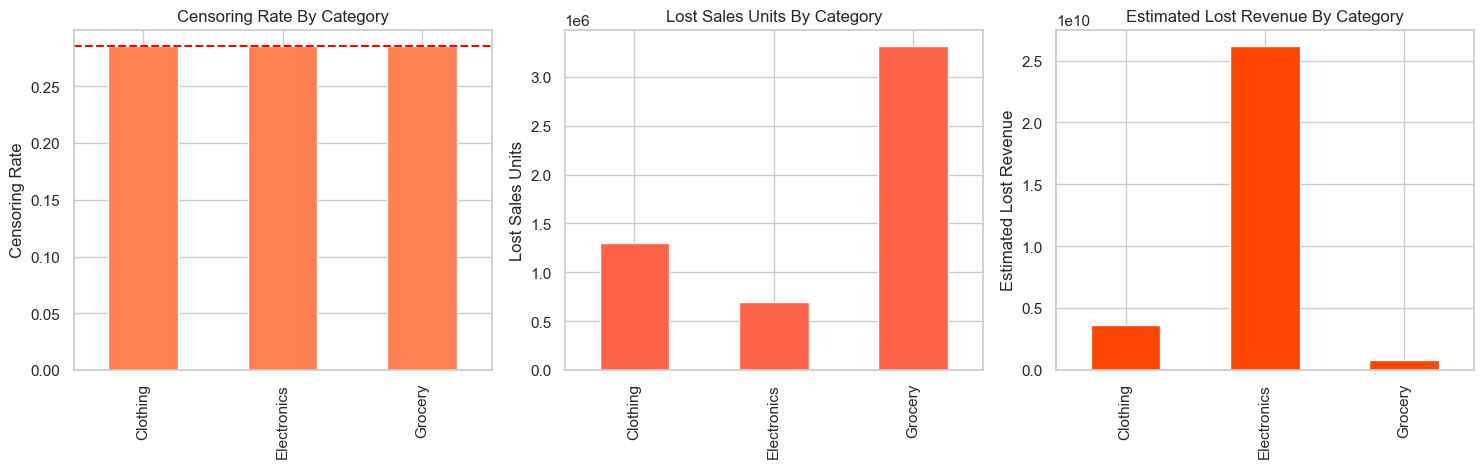

In [15]:
# Visualize
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

category_censoring.plot(x = 'category', y = 'censoring_rate', kind = 'bar', ax = axes[0], legend = False, color = 'coral')
axes[0].set_title('Censoring Rate By Category')
axes[0].set_ylabel('Censoring Rate')
axes[0].set_xlabel('')
axes[0].axhline(y = df['stockout_flag'].mean(), color = 'red', linestyle = '--', label = 'Overall Average')

# lost units
category_censoring.plot(x = 'category', y = 'lost_sales_units', kind = 'bar', ax = axes[1], legend = False, color = 'tomato')
axes[1].set_title('Lost Sales Units By Category')
axes[1].set_ylabel('Lost Sales Units')
axes[1].set_xlabel('')

# Lost Revenue
category_censoring.plot(x = 'category', y = 'estimated_lost_revenue', kind = 'bar', ax= axes[2], legend = False, color = 'orangered')
axes[2].set_title('Estimated Lost Revenue By Category')
axes[2].set_ylabel('Estimated Lost Revenue')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

## 6. Region-Level Analysis

In [18]:
# By region
region_censoring = df.groupby('region').agg({
    'stockout_flag': ['sum', 'mean'],
    'lost_sales': 'sum',
    'sales_qty': 'sum',
    'demand': 'sum',
    'final_price': 'mean'
}).reset_index()

region_censoring.columns = [
    'region', 'stockouts_count', 'censoring_rate', 'lost_sales_units',
    'actual_sales_units', 'true_demand_units', 'avg_price'
]

In [19]:
region_censoring['estimated_lost_revenue'] = region_censoring['lost_sales_units'] * region_censoring['avg_price']
region_censoring.sort_values(by = 'censoring_rate', ascending = False)

print("\nCENSORING BY REGION")
print("="*70)
display(region_censoring[['region', 'censoring_rate', 'lost_sales_units', 'estimated_lost_revenue']])


CENSORING BY REGION


,region,censoring_rate,lost_sales_units,estimated_lost_revenue
0,Delhi,0.286182,761503,9.016894e+09
1,Gujarat,0.285302,429426,5.022330e+09
2,Karnataka,0.284531,940859,1.475568e+10
3,Kerala,0.285598,847410,1.249524e+10
4,Maharashtra,0.285652,1648084,1.721193e+10
5,Tamil Nadu,0.284489,688452,1.140695e+10


In [20]:
# Heatmap: Region v/s Category
pivot_censoring = df.pivot_table(
    index = 'region',
    columns = 'category',
    values = 'stockout_flag',
    aggfunc = 'mean'
); pivot_censoring

category,Clothing,Electronics,Grocery
region,,,
Delhi,0.286567,0.286098,0.285815
Gujarat,0.283611,0.288345,0.284965
Karnataka,0.285011,0.284289,0.284253
Kerala,0.284337,0.284760,0.287838
Maharashtra,0.285358,0.286276,0.285518
Tamil Nadu,0.286216,0.283378,0.284531


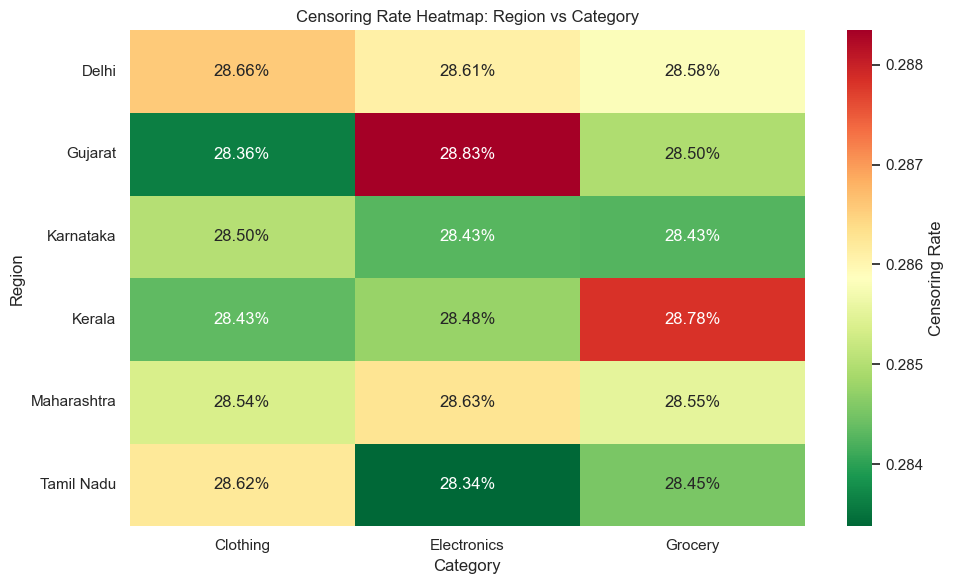

In [21]:
plt.figure(figsize = (10, 6))
sns.heatmap(pivot_censoring, annot = True, fmt = '.2%', cmap = 'RdYlGn_r', cbar_kws = {'label': 'Censoring Rate'})
plt.title('Censoring Rate Heatmap: Region vs Category')
plt.xlabel('Category')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

## 7. Time Series Censoring Trends

In [24]:
df['year_month'] = df['date'].dt.to_period('M')

In [25]:
monthly_censoring = df.groupby('year_month').agg({
    'stockout_flag': 'mean',
    'lost_sales': 'sum',
    'sales_qty': 'sum',
}).reset_index()

monthly_censoring['year_month'] = monthly_censoring['year_month'].astype(str)

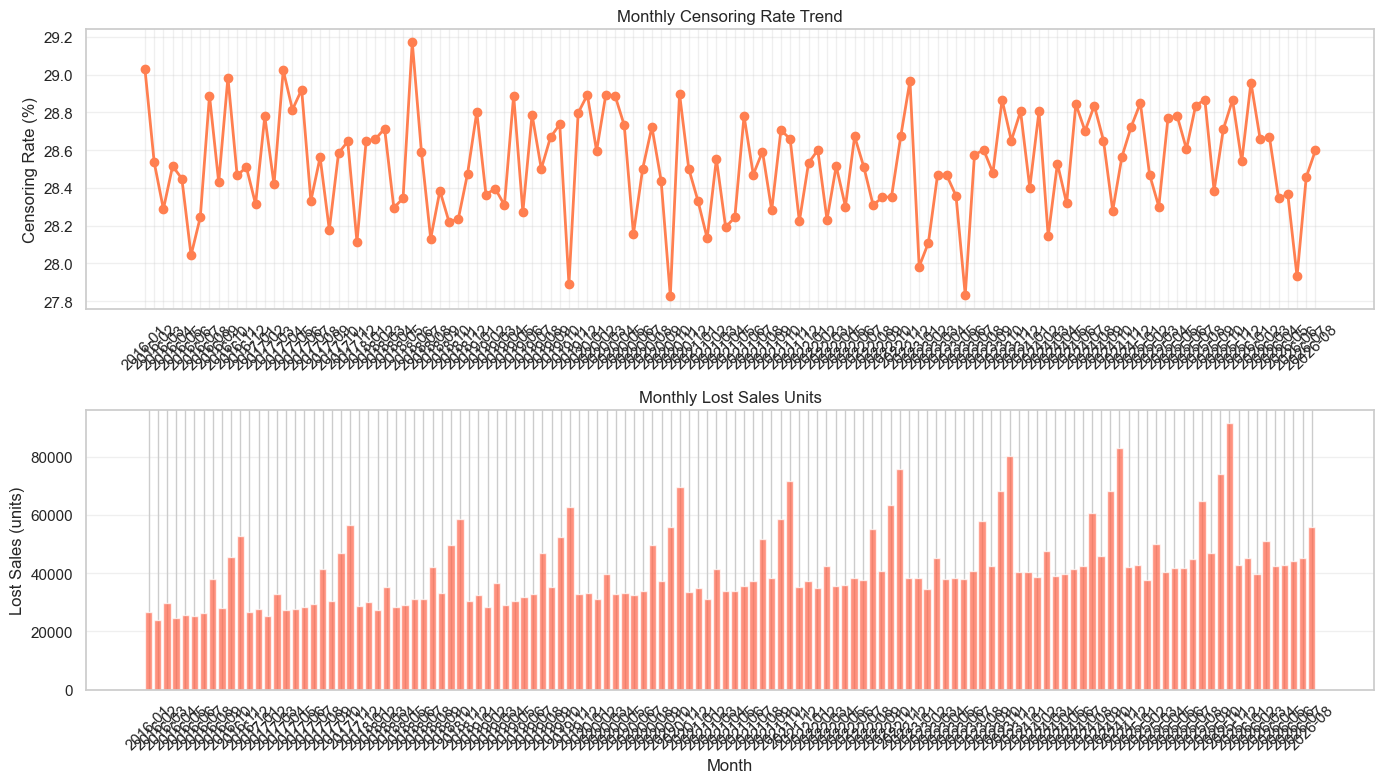

In [32]:
# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Censoring rate over time
axes[0].plot(monthly_censoring['year_month'], monthly_censoring['stockout_flag']*100, 
              marker='o', linewidth=2, markersize=6, color='coral')
axes[0].set_title('Monthly Censoring Rate Trend')
axes[0].set_ylabel('Censoring Rate (%)')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Lost sales over time
axes[1].bar(monthly_censoring['year_month'], monthly_censoring['lost_sales'], 
             color='tomato', alpha=0.7)
axes[1].set_title('Monthly Lost Sales Units')
axes[1].set_ylabel('Lost Sales (units)')
axes[1].set_xlabel('Month')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [33]:
print(f"\nTrend Summary:")
early_rate = monthly_censoring['stockout_flag'].iloc[:6].mean()
late_rate = monthly_censoring['stockout_flag'].iloc[-6:].mean()
print(f"  Early months censoring: {early_rate*100:.2f}%")
print(f"  Recent months censoring: {late_rate*100:.2f}%")
print(f"  Trend: {'↑ INCREASING' if late_rate > early_rate else '↓ DECREASING'}")


Trend Summary:
  Early months censoring: 28.48%
  Recent months censoring: 28.39%
  Trend: ↓ DECREASING
